# Batch Normalization 

Batch normalization was introduced in Sergey Ioffe's and Christian Szegedy's 2015 paper [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/pdf/1502.03167.pdf). The idea is that, instead of just normalizing the inputs to the network, we normalize the inputs to _layers within_ the network. 
> It's called **batch** normalization because during training, we normalize each layer's inputs by using the mean and variance of the values in the current *batch*.

## Batch Normalization in PyTorch<a id="implementation_1"></a>

This section of the notebook shows you one way to add batch normalization to a neural network built in PyTorch. 

The following cells import the packages we need in the notebook and load the MNIST dataset to use in our experiments.

In [1]:
%matplotlib inline

import numpy as np
import torch
import matplotlib.pyplot as plt

# number of subprocesses to use for data loading
num_threads = 24
# Device types: cpu, xpu, cuda
device_type = "xpu"

In [2]:
# Use GPU when available
device = torch.device(device_type)
print(device)

xpu


In [3]:
from torchvision import datasets
import torchvision.transforms as transforms

# how many samples per batch to load
batch_size = 64

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# get the training and test datasets
train_data = datasets.MNIST(root='data', train=True,
                            download=True, transform=transform)

test_data = datasets.MNIST(root='data', train=False,
                           download=True, transform=transform)

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           num_workers=num_threads)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
                                          num_workers=num_threads)

### Visualize the data

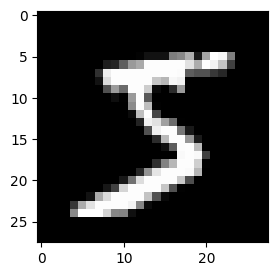

In [4]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# get one image from the batch
img = np.squeeze(images[0])

fig = plt.figure(figsize = (3,3)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')

## Neural network classes for testing

The following class, `NeuralNet`, allows us to create identical neural networks **with and without batch normalization** to compare. The code is heavily documented, but there is also some additional discussion later. You do not need to read through it all before going through the rest of the notebook, but the comments within the code blocks may answer some of your questions.

*About the code:*
>We are defining a simple MLP for classification; this design choice was made to support the discussion related to batch normalization and not to get the best classification accuracy.

### (Important) Model Details

There are quite a few comments in the code, so those should answer most of your questions. However, let's take a look at the most important lines.

We add batch normalization to layers inside the `__init__` function. Here are some important points about that code:
1. Layers with batch normalization do **not** include a bias term.
2. We use PyTorch's [BatchNorm1d](https://pytorch.org/docs/stable/nn.html#batchnorm1d) function to handle the math. This is the function you use to operate on linear layer outputs; you'll use [BatchNorm2d](https://pytorch.org/docs/stable/nn.html#batchnorm2d) for 2D outputs like filtered images from convolutional layers. 
3. We add the batch normalization layer **before** calling the activation function.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self, use_batch_norm, input_size=784, hidden_dim=256, output_size=10):
        """
        Creates a PyTorch net using the given parameters.
        
        :param use_batch_norm: bool
            Pass True to create a network that uses batch normalization; False otherwise
            Note: this network will not use batch normalization on layers that do not have an
            activation function.
        """
        super(NeuralNet, self).__init__() # init super
        
        # Default layer sizes
        self.input_size = input_size # (28*28 images)
        self.hidden_dim = hidden_dim
        self.output_size = output_size # (number of classes)
        # Keep track of whether or not this network uses batch normalization.
        self.use_batch_norm = use_batch_norm
        
        # define hidden linear layers, with optional batch norm on their outputs
        # layers with batch_norm applied have no bias term
        if use_batch_norm:
            self.fc1 = nn.Linear(input_size, hidden_dim*2, bias=False)
            self.batch_norm1 = nn.BatchNorm1d(hidden_dim*2)
        else:
            self.fc1 = nn.Linear(input_size, hidden_dim*2)
            
        # define *second* hidden linear layers, with optional batch norm on their outputs
        if use_batch_norm:
            self.fc2 = nn.Linear(hidden_dim*2, hidden_dim, bias=False)
            self.batch_norm2 = nn.BatchNorm1d(hidden_dim)
        else:
            self.fc2 = nn.Linear(hidden_dim*2, hidden_dim)
        
        # third and final, fully-connected layer
        self.fc3 = nn.Linear(hidden_dim, output_size)
        
        
    def forward(self, x):
        # flatten image
        x = x.view(-1, 28*28)
        # all hidden layers + optional batch norm + relu activation
        x = self.fc1(x)
        if self.use_batch_norm:
            x = self.batch_norm1(x)
        x = F.relu(x)
        # second layer
        x = self.fc2(x)
        if self.use_batch_norm:
            x = self.batch_norm2(x)
        x = F.relu(x)
        # third layer, no batch norm or activation
        x = self.fc3(x)
        return x


### Create two different models for testing

* `net_batchnorm` is a linear classification model **with** batch normalization applied to the output of its hidden layers
* `net_no_norm` is a plain MLP, without batch normalization

Besides the normalization layers, everthing about these models is the same.

In [6]:
net_batchnorm = NeuralNet(use_batch_norm=True)
net_batchnorm.to(device)
net_no_norm = NeuralNet(use_batch_norm=False)
net_no_norm.to(device)

print(net_batchnorm)
print()
print(net_no_norm)

NeuralNet(
  (fc1): Linear(in_features=784, out_features=512, bias=False)
  (batch_norm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=False)
  (batch_norm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

NeuralNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


---
## Training

The below `train` function will take in a model and some number of epochs. We'll use cross entropy loss and stochastic gradient descent for optimization. This function returns the losses, recorded after each epoch, so that we can display and compare the behavior of different models.

#### `.train()` mode
Note that we tell our model whether or not it should be in training mode, `model.train()`. This is an important step because batch normalization has different behavior during training on a batch or testing/evaluating on a larger dataset.

In [7]:
def train(model, n_epochs=10):
    # number of epochs to train the model
    n_epochs = n_epochs
    # track losses
    losses = []
        
    # optimization strategy 
    # specify loss function (categorical cross-entropy)
    criterion = nn.CrossEntropyLoss()

    # specify optimizer (stochastic gradient descent) and learning rate = 0.01
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    # set the model to training mode
    model.train()
    
    for epoch in range(1, n_epochs+1):
        # monitor training loss
        train_loss = 0.0

        ###################
        # train the model #
        ###################
        batch_count = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            # calculate the loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # perform a single optimization step (parameter update)
            optimizer.step()
            # update average training loss
            train_loss += loss.item() # add up avg batch loss
            batch_count +=1                

        # print training statistics 
        losses.append(train_loss/batch_count)
        print('Epoch: {} \tTraining Loss: {:.6f}'.format(
            epoch, 
            train_loss/batch_count))
    
    # return all recorded batch losses
    return losses
        
      

### Comparing Models

In the below cells, we train our two different models and compare their trainining loss over time.

In [8]:
import time

In [9]:
# batchnorm model losses
# this may take some time to train
tic = time.time()
losses_batchnorm = train(net_batchnorm)
toc = time.time()
print("train time: %6.2f seconds" % (toc-tic))

Epoch: 1 	Training Loss: 0.392841
Epoch: 2 	Training Loss: 0.164568
Epoch: 3 	Training Loss: 0.114382
Epoch: 4 	Training Loss: 0.085011
Epoch: 5 	Training Loss: 0.064953
Epoch: 6 	Training Loss: 0.050271
Epoch: 7 	Training Loss: 0.039208
Epoch: 8 	Training Loss: 0.030702
Epoch: 9 	Training Loss: 0.024206
Epoch: 10 	Training Loss: 0.019256
train time:  22.59 seconds


### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

Train on CPU:
```
Epoch: 1 	Training Loss: 0.562245
Epoch: 2 	Training Loss: 0.203395
Epoch: 3 	Training Loss: 0.138875
Epoch: 4 	Training Loss: 0.104238
Epoch: 5 	Training Loss: 0.081380
Epoch: 6 	Training Loss: 0.064781
Epoch: 7 	Training Loss: 0.052058
Epoch: 8 	Training Loss: 0.042003
Epoch: 9 	Training Loss: 0.033934
Epoch: 10 	Training Loss: 0.027514
train time:  78.43 seconds
```

CPU utilization 100% all 12 threads.

Train on GPU:
```
Epoch: 1 	Training Loss: 0.551107
Epoch: 2 	Training Loss: 0.202488
Epoch: 3 	Training Loss: 0.138793
Epoch: 4 	Training Loss: 0.104155
Epoch: 5 	Training Loss: 0.081332
Epoch: 6 	Training Loss: 0.064745
Epoch: 7 	Training Loss: 0.052065
Epoch: 8 	Training Loss: 0.042078
Epoch: 9 	Training Loss: 0.034060
Epoch: 10 	Training Loss: 0.027618
train time:  19.24 seconds
```

GPU utilization:
```
while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done

GeForce GTX 1060, 0, 55, 29 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 30 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 28 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 32 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 32 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 26 %, 9 %, 6078 MiB, 5261 MiB, 817 MiB
GeForce GTX 1060, 0, 56, 30 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 30 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 10 %, 2 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 28 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 28 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 26 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 29 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 26 %, 9 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 21 %, 7 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 56, 4 %, 1 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 25 %, 9 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 29 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 29 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 30 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 25 %, 9 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 27 %, 9 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 23 %, 7 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 6 %, 1 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 57, 25 %, 9 %, 6078 MiB, 5262 MiB, 816 MiB
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

Train on GPU:
```
Epoch: 1 	Training Loss: 0.391647
Epoch: 2 	Training Loss: 0.162148
Epoch: 3 	Training Loss: 0.112234
Epoch: 4 	Training Loss: 0.083449
Epoch: 5 	Training Loss: 0.063913
Epoch: 6 	Training Loss: 0.049591
Epoch: 7 	Training Loss: 0.038733
Epoch: 8 	Training Loss: 0.030418
Epoch: 9 	Training Loss: 0.024027
Epoch: 10 	Training Loss: 0.019167
train time:  22.37 seconds
```

```
$ top

top - 23:03:15 up 48 min,  1 user,  load average: 0.60, 1.15, 3.03
Tasks: 642 total,   2 running, 639 sleeping,   0 stopped,   1 zombie
%Cpu(s):  5.5 us,  2.4 sy,  0.0 ni, 91.0 id,  1.0 wa,  0.0 hi,  0.1 si,  0.0 st 
MiB Mem :  31434.1 total,  23092.8 free,   5208.1 used,   3838.1 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  26225.9 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
  14022 eka       20   0   10.7g   1.1g 457984 R  88.7   3.6   0:46.47 python               
   3203 eka       20   0 5235852 304488 132304 S   2.3   0.9   2:30.39 gnome-shell          
  16836 eka       20   0   10.6g 760396  59944 S   2.0   2.4   0:00.06 pt_data_worker       
  16837 eka       20   0   10.6g 760232  59780 S   2.0   2.4   0:00.06 pt_data_worker       
  16839 eka       20   0   10.6g 760424  59972 S   2.0   2.4   0:00.06 pt_data_worker       
  16841 eka       20   0   10.6g 760424  59972 S   2.0   2.4   0:00.06 pt_data_worker       
  16845 eka       20   0   10.6g 760424  59972 S   2.0   2.4   0:00.06 pt_data_worker       
  16852 eka       20   0   10.6g 760232  59780 S   2.0   2.4   0:00.06 pt_data_worker       
  16854 eka       20   0   10.6g 760576  60124 S   2.0   2.4   0:00.06 pt_data_worker       
  16856 eka       20   0   10.6g 760232  59780 S   2.0   2.4   0:00.06 pt_data_worker       
  16838 eka       20   0   10.6g 760248  59796 S   1.7   2.4   0:00.05 pt_data_worker       
  16840 eka       20   0   10.6g 760600  60148 S   1.7   2.4   0:00.05 pt_data_worker       
  16842 eka       20   0   10.6g 760624  60172 S   1.7   2.4   0:00.05 pt_data_worker       
  16843 eka       20   0   10.6g 760424  59972 S   1.7   2.4   0:00.05 pt_data_worker       
  16844 eka       20   0   10.6g 760816  60172 S   1.7   2.4   0:00.05 pt_data_worker       
  16846 eka       20   0   10.6g 760784  60332 S   1.7   2.4   0:00.05 pt_data_worker       
  16848 eka       20   0   10.6g 760616  60164 S   1.7   2.4   0:00.05 pt_data_worker
...
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2401/2401 MHz;   0% RC6;    20084 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    1.03% |▌                                               |      0%      0%
         Blitter    6.14% |███                                             |      3%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   45.69% |██████████████████████                          |      4%      0%

  PID   Render/3D      Blitter        Video      VideoEnhance    Compute     NAME           
14022 |            ||▊           ||            ||            ||█████▊      | python         

```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      32.12      20.55       0.00
 SKT   0     0.00     0.00      31.79      20.49       0.00
 SKT   0     0.00     0.00      32.42      20.71       0.00
 SKT   0     0.00     0.00      32.92      21.57       0.00
 SKT   0     0.00     0.00      32.16      20.48       0.00
 SKT   0     0.00     0.00      34.31      22.93       0.00
 SKT   0     0.00     0.00      34.99      23.12       0.00
 SKT   0     0.00     0.00      33.74      22.20       0.00
 SKT   0     0.00     0.00      31.60      20.00       0.00
 SKT   0     0.00     0.00      30.48      19.16       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+----------------------------+
| Device ID                   | 1                          |
+-----------------------------+----------------------------+
| GPU Utilization (%)         | N/A                        |
| EU Array Active (%)         | N/A                        |
| EU Array Stall (%)          | N/A                        |
| EU Array Idle (%)           | N/A                        |
|                             |                            |
| Compute Engine Util (%)     | N/A                        |
| Render Engine Util (%)      | Engine 0: 0                |
| Media Engine Util (%)       | N/A                        |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0   |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0   |
| Copy Engine Util (%)        | Engine 0: 7                |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0   |
| 3D Engine Util (%)          | N/A                        |
+-----------------------------+----------------------------+
| Reset                       | N/A                        |
| Programming Errors          | N/A                        |
| Driver Errors               | N/A                        |
| Cache Errors Correctable    | N/A                        |
| Cache Errors Uncorrectable  | N/A                        |
| Mem Errors Correctable      | N/A                        |
| Mem Errors Uncorrectable    | N/A                        |
+-----------------------------+----------------------------+
| GPU Power (W)               | 85                         |
| GPU Frequency (MHz)         | 2400                       |
| Media Engine Freq (MHz)     | N/A                        |
| GPU Core Temperature (C)    | N/A                        |
| GPU Memory Temperature (C)  | N/A                        |
| GPU Memory Read (kB/s)      | N/A                        |
| GPU Memory Write (kB/s)     | N/A                        |
| GPU Memory Bandwidth (%)    | N/A                        |
| GPU Memory Used (MiB)       | 520                        |
| GPU Memory Util (%)         | 3                          |
| Xe Link Throughput (kB/s)   | N/A                        |
+-----------------------------+----------------------------+

```

In [10]:
# *no* norm model losses
# you should already start to see a difference in training losses
tic = time.time()
losses_no_norm = train(net_no_norm)
toc = time.time()
print("train time: %6.2f seconds" % (toc-tic))

Epoch: 1 	Training Loss: 1.562785
Epoch: 2 	Training Loss: 0.508349
Epoch: 3 	Training Loss: 0.378634
Epoch: 4 	Training Loss: 0.331412
Epoch: 5 	Training Loss: 0.301825
Epoch: 6 	Training Loss: 0.279207
Epoch: 7 	Training Loss: 0.260282
Epoch: 8 	Training Loss: 0.243677
Epoch: 9 	Training Loss: 0.228689
Epoch: 10 	Training Loss: 0.215028
train time:  20.73 seconds


### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

Train on CPU:
```
Epoch: 1 	Training Loss: 1.613782
Epoch: 2 	Training Loss: 0.511284
Epoch: 3 	Training Loss: 0.378044
Epoch: 4 	Training Loss: 0.332367
Epoch: 5 	Training Loss: 0.303729
Epoch: 6 	Training Loss: 0.281580
Epoch: 7 	Training Loss: 0.262719
Epoch: 8 	Training Loss: 0.245980
Epoch: 9 	Training Loss: 0.230799
Epoch: 10 	Training Loss: 0.216863
train time:  72.76 seconds
```

CPU utilization 100% all 12 threads.

Train on GPU:
```
Epoch: 1 	Training Loss: 1.566902
Epoch: 2 	Training Loss: 0.505788
Epoch: 3 	Training Loss: 0.378503
Epoch: 4 	Training Loss: 0.333685
Epoch: 5 	Training Loss: 0.305176
Epoch: 6 	Training Loss: 0.282517
Epoch: 7 	Training Loss: 0.262915
Epoch: 8 	Training Loss: 0.245338
Epoch: 9 	Training Loss: 0.229480
Epoch: 10 	Training Loss: 0.215092
train time:  17.07 seconds
```

GPU utilization:
```
while sleep 0.2; do nvidia-smi --query-gpu=name,index,temperature.gpu,utilization.gpu,utilization.memory,memory.total,memory.free,memory.used --format=csv,noheader; done

GeForce GTX 1060, 0, 58, 27 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 25 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 26 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 27 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 25 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 6 %, 1 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 26 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 27 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 58, 28 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 25 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 27 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 27 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 27 %, 10 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 6 %, 1 %, 6078 MiB, 5262 MiB, 816 MiB
GeForce GTX 1060, 0, 59, 26 %, 11 %, 6078 MiB, 5262 MiB, 816 MiB
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

Train on GPU:
```
Epoch: 1 	Training Loss: 0.202955
Epoch: 2 	Training Loss: 0.191322
Epoch: 3 	Training Loss: 0.180679
Epoch: 4 	Training Loss: 0.170930
Epoch: 5 	Training Loss: 0.161961
Epoch: 6 	Training Loss: 0.153684
Epoch: 7 	Training Loss: 0.146060
Epoch: 8 	Training Loss: 0.139008
Epoch: 9 	Training Loss: 0.132446
Epoch: 10 	Training Loss: 0.126313
train time:  20.10 seconds
```

```
$ top

top - 23:10:38 up 56 min,  1 user,  load average: 2.04, 1.63, 2.52
Tasks: 628 total,   2 running, 625 sleeping,   0 stopped,   1 zombie
%Cpu(s):  6.3 us,  2.3 sy,  0.0 ni, 89.8 id,  1.4 wa,  0.0 hi,  0.1 si,  0.0 st 
MiB Mem :  31434.1 total,  22945.3 free,   5350.5 used,   3843.5 buff/cache     
MiB Swap:   8192.0 total,   8192.0 free,      0.0 used.  26083.6 avail Mem 

    PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND              
  14022 eka       20   0   10.7g   1.1g 457984 R  83.7   3.6   2:20.99 python               
  22483 eka       20   0   10.6g 760368  59888 S   3.0   2.4   0:00.09 pt_data_worker       
  22471 eka       20   0   10.6g 760732  60252 S   2.7   2.4   0:00.08 pt_data_worker       
  22462 eka       20   0   10.6g 760452  60164 S   2.3   2.4   0:00.07 pt_data_worker       
  22463 eka       20   0   10.6g 759608  59320 S   2.3   2.4   0:00.07 pt_data_worker       
  22465 eka       20   0   10.6g 760260  59972 S   2.3   2.4   0:00.07 pt_data_worker       
  22467 eka       20   0   10.6g 760452  60164 S   2.3   2.4   0:00.07 pt_data_worker       
  22470 eka       20   0   10.6g 760768  60288 S   2.3   2.4   0:00.07 pt_data_worker       
  22472 eka       20   0   10.6g 761000  60520 S   2.3   2.4   0:00.07 pt_data_worker       
  22474 eka       20   0   10.6g 760456  60248 S   2.3   2.4   0:00.07 pt_data_worker       
  22475 eka       20   0   10.6g 760452  60164 S   2.3   2.4   0:00.07 pt_data_worker       
  22476 eka       20   0   10.6g 760452  59972 S   2.3   2.4   0:00.07 pt_data_worker       
  22478 eka       20   0   10.6g 760260  59972 S   2.3   2.4   0:00.07 pt_data_worker       
  22480 eka       20   0   10.6g 760452  60164 S   2.3   2.4   0:00.07 pt_data_worker       
  22482 eka       20   0   10.6g 760068  59780 S   2.3   2.4   0:00.07 pt_data_worker       
  22485 eka       20   0   10.6g 760568  60088 S   2.3   2.4   0:00.07 pt_data_worker       
  22464 eka       20   0   10.6g 760428  60140 S   2.0   2.4   0:00.06 pt_data_worker
...
```

```
$ sudo intel_gpu_top
intel-gpu-top: Intel Dg2 (Gen12) @ /dev/dri/card2 - 2394/2395 MHz;   0% RC6;    13219 irqs/s

         ENGINES     BUSY                                                    MI_SEMA MI_WAIT
       Render/3D    0.05% |▏                                               |      0%      0%
         Blitter    5.09% |██▌                                             |      4%      0%
           Video    0.00% |                                                |      0%      0%
    VideoEnhance    0.00% |                                                |      0%      0%
         Compute   35.31% |█████████████████                               |      5%      0%

  PID   Render/3D      Blitter        Video      VideoEnhance    Compute     NAME           
14022 |            ||▋           ||            ||            ||████▌       | python         
...
```

```
$ sudo pcm -silent | grep " SKT   0"
MEM (GB)->|  READ |  WRITE | CPU energy | PP0 energy | PP1 energy |
...
 SKT   0     0.00     0.00      32.50      20.83       0.00
 SKT   0     0.00     0.00      33.15      21.63       0.00
 SKT   0     0.00     0.00      33.08      21.34       0.00
 SKT   0     0.00     0.00      32.24      20.85       0.00
 SKT   0     0.00     0.00      31.95      20.34       0.00
 SKT   0     0.00     0.00      31.74      20.31       0.00
 SKT   0     0.00     0.00      34.06      22.19       0.00
 SKT   0     0.00     0.00      31.88      20.45       0.00
 SKT   0     0.00     0.00      31.27      19.60       0.00
 SKT   0     0.00     0.00      31.59      20.13       0.00
...
```

```
$ sudo xpu-smi stats -d 1
+-----------------------------+-----------------------------+
| Device ID                   | 1                           |
+-----------------------------+-----------------------------+
| GPU Utilization (%)         | N/A                         |
| EU Array Active (%)         | N/A                         |
| EU Array Stall (%)          | N/A                         |
| EU Array Idle (%)           | N/A                         |
|                             |                             |
| Compute Engine Util (%)     | N/A                         |
| Render Engine Util (%)      | Engine 0: 0                 |
| Media Engine Util (%)       | N/A                         |
| Decoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Encoder Engine Util (%)     | Engine 0: 0, Engine 1: 0    |
| Copy Engine Util (%)        | Engine 0: 5                 |
| Media EM Engine Util (%)    | Engine 0: 0, Engine 1: 0    |
| 3D Engine Util (%)          | N/A                         |
+-----------------------------+-----------------------------+
| Reset                       | N/A                         |
| Programming Errors          | N/A                         |
| Driver Errors               | N/A                         |
| Cache Errors Correctable    | N/A                         |
| Cache Errors Uncorrectable  | N/A                         |
| Mem Errors Correctable      | N/A                         |
| Mem Errors Uncorrectable    | N/A                         |
+-----------------------------+-----------------------------+
| GPU Power (W)               | 84                          |
| GPU Frequency (MHz)         | 2400                        |
| Media Engine Freq (MHz)     | N/A                         |
| GPU Core Temperature (C)    | N/A                         |
| GPU Memory Temperature (C)  | N/A                         |
| GPU Memory Read (kB/s)      | N/A                         |
| GPU Memory Write (kB/s)     | N/A                         |
| GPU Memory Bandwidth (%)    | N/A                         |
| GPU Memory Used (MiB)       | 522                         |
| GPU Memory Util (%)         | 3                           |
| Xe Link Throughput (kB/s)   | N/A                         |
+-----------------------------+-----------------------------+

```

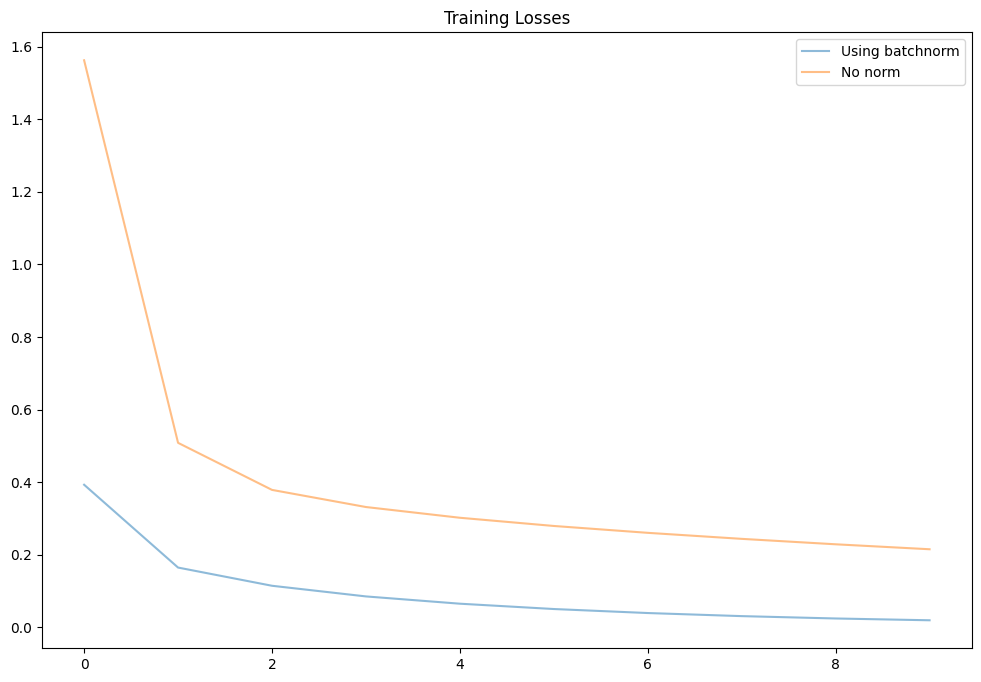

In [11]:
# compare
fig, ax = plt.subplots(figsize=(12,8))
#losses_batchnorm = np.array(losses_batchnorm)
#losses_no_norm = np.array(losses_no_norm)
plt.plot(losses_batchnorm, label='Using batchnorm', alpha=0.5)
plt.plot(losses_no_norm, label='No norm', alpha=0.5)
plt.title("Training Losses")
plt.legend()

---
## Testing

You should see that the model with batch normalization, starts off with a lower training loss and, over ten epochs of training, gets to a training loss that is noticeably lower than our model without normalization.

Next, let's see how both these models perform on our test data! Below, we have a function `test` that takes in a model and a parameter `train` (True or False) which indicates whether the model should be in training or evaulation mode. This is for comparison purposes, later. This function will calculate some test stastics including the overall test accuracy of a passed in model.


In [12]:
def test(model, train):
    # initialize vars to monitor test loss and accuracy
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))
    test_loss = 0.0

    # set model to train or evaluation mode
    # just to see the difference in behavior
    if(train==True):
        model.train()
    if(train==False):
        model.eval()
    
    # loss criterion
    criterion = nn.CrossEntropyLoss()
    
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)
        batch_size = data.size(0)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss
        loss = criterion(output, target)
        # update average test loss 
        test_loss += loss.item()*batch_size
        # convert output probabilities to predicted class
        _, pred = torch.max(output, 1)
        # compare predictions to true label
        correct = np.squeeze(pred.eq(target.data.view_as(pred)))
        # calculate test accuracy for each object class
        for i in range(batch_size):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

    print('Test Loss: {:.6f}\n'.format(test_loss/len(test_loader.dataset)))

    for i in range(10):
        if class_total[i] > 0:
            print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
                str(i), 100 * class_correct[i] / class_total[i],
                np.sum(class_correct[i]), np.sum(class_total[i])))
        else:
            print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

    print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
        100. * np.sum(class_correct) / np.sum(class_total),
        np.sum(class_correct), np.sum(class_total)))

### Training and Evaluation Mode

Setting a model to evaluation mode is important for models with batch normalization layers!

>* Training mode means that the batch normalization layers will use **batch** statistics to calculate the batch norm. 
* Evaluation mode, on the other hand, uses the estimated **population** mean and variance from the entire training set, which should give us increased performance on this test data! 

In [13]:
# test batchnorm case, in *train* mode
tic = time.time()
test(net_batchnorm, train=True)
toc = time.time()
print("test time: %6.2f seconds" % (toc-tic))

Test Loss: 0.082558

Test Accuracy of     0: 98% (968/980)
Test Accuracy of     1: 99% (1128/1135)
Test Accuracy of     2: 96% (999/1032)
Test Accuracy of     3: 97% (987/1010)
Test Accuracy of     4: 97% (957/982)
Test Accuracy of     5: 97% (867/892)
Test Accuracy of     6: 97% (932/958)
Test Accuracy of     7: 97% (1001/1028)
Test Accuracy of     8: 97% (945/974)
Test Accuracy of     9: 96% (972/1009)

Test Accuracy (Overall): 97% (9756/10000)
test time:   0.79 seconds


### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

Test on CPU:
```
Test Loss: 0.085919

Test Accuracy of     0: 98% (969/980)
Test Accuracy of     1: 99% (1124/1135)
Test Accuracy of     2: 96% (998/1032)
Test Accuracy of     3: 96% (978/1010)
Test Accuracy of     4: 97% (954/982)
Test Accuracy of     5: 96% (862/892)
Test Accuracy of     6: 97% (930/958)
Test Accuracy of     7: 96% (996/1028)
Test Accuracy of     8: 96% (941/974)
Test Accuracy of     9: 96% (970/1009)

Test Accuracy (Overall): 97% (9722/10000)
test time:   0.39 seconds
```

Test on GPU:
```
Test Loss: 0.089803

Test Accuracy of     0: 98% (968/980)
Test Accuracy of     1: 99% (1125/1135)
Test Accuracy of     2: 96% (1000/1032)
Test Accuracy of     3: 97% (982/1010)
Test Accuracy of     4: 97% (956/982)
Test Accuracy of     5: 96% (862/892)
Test Accuracy of     6: 96% (927/958)
Test Accuracy of     7: 96% (987/1028)
Test Accuracy of     8: 96% (939/974)
Test Accuracy of     9: 96% (970/1009)

Test Accuracy (Overall): 97% (9716/10000)
test time:   0.91 seconds
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

Test on GPU:
```
Test Loss: 0.082558

Test Accuracy of     0: 98% (968/980)
Test Accuracy of     1: 99% (1128/1135)
Test Accuracy of     2: 96% (999/1032)
Test Accuracy of     3: 97% (987/1010)
Test Accuracy of     4: 97% (957/982)
Test Accuracy of     5: 97% (867/892)
Test Accuracy of     6: 97% (932/958)
Test Accuracy of     7: 97% (1001/1028)
Test Accuracy of     8: 97% (945/974)
Test Accuracy of     9: 96% (972/1009)

Test Accuracy (Overall): 97% (9756/10000)
test time:   0.79 seconds
```

In [14]:
# test batchnorm case, in *evaluation* mode
tic = time.time()
test(net_batchnorm, train=False)
toc = time.time()
print("test time: %6.2f seconds" % (toc-tic))

Test Loss: 0.070189

Test Accuracy of     0: 99% (972/980)
Test Accuracy of     1: 99% (1127/1135)
Test Accuracy of     2: 97% (1009/1032)
Test Accuracy of     3: 97% (988/1010)
Test Accuracy of     4: 97% (955/982)
Test Accuracy of     5: 97% (866/892)
Test Accuracy of     6: 97% (933/958)
Test Accuracy of     7: 97% (1000/1028)
Test Accuracy of     8: 95% (935/974)
Test Accuracy of     9: 97% (988/1009)

Test Accuracy (Overall): 97% (9773/10000)
test time:   0.76 seconds


### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

Test on CPU:
```
Test Loss: 0.073723

Test Accuracy of     0: 98% (969/980)
Test Accuracy of     1: 99% (1124/1135)
Test Accuracy of     2: 98% (1013/1032)
Test Accuracy of     3: 97% (983/1010)
Test Accuracy of     4: 97% (958/982)
Test Accuracy of     5: 97% (866/892)
Test Accuracy of     6: 97% (936/958)
Test Accuracy of     7: 96% (994/1028)
Test Accuracy of     8: 95% (935/974)
Test Accuracy of     9: 98% (990/1009)

Test Accuracy (Overall): 97% (9768/10000)
test time:   0.42 seconds
```

Test on GPU:
```
Test Loss: 0.074932

Test Accuracy of     0: 98% (967/980)
Test Accuracy of     1: 99% (1126/1135)
Test Accuracy of     2: 97% (1011/1032)
Test Accuracy of     3: 97% (989/1010)
Test Accuracy of     4: 97% (956/982)
Test Accuracy of     5: 97% (872/892)
Test Accuracy of     6: 97% (933/958)
Test Accuracy of     7: 97% (1002/1028)
Test Accuracy of     8: 96% (938/974)
Test Accuracy of     9: 97% (983/1009)

Test Accuracy (Overall): 97% (9777/10000)
test time:   0.93 seconds
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

Test on GPU:
```
Test Loss: 0.070189

Test Accuracy of     0: 99% (972/980)
Test Accuracy of     1: 99% (1127/1135)
Test Accuracy of     2: 97% (1009/1032)
Test Accuracy of     3: 97% (988/1010)
Test Accuracy of     4: 97% (955/982)
Test Accuracy of     5: 97% (866/892)
Test Accuracy of     6: 97% (933/958)
Test Accuracy of     7: 97% (1000/1028)
Test Accuracy of     8: 95% (935/974)
Test Accuracy of     9: 97% (988/1009)

Test Accuracy (Overall): 97% (9773/10000)
test time:   0.76 seconds
```

In [15]:
# for posterity, test no norm case in eval mode
tic = time.time()
test(net_no_norm, train=False)
toc = time.time()
print("test time: %6.2f seconds" % (toc-tic))

Test Loss: 0.207112

Test Accuracy of     0: 98% (963/980)
Test Accuracy of     1: 98% (1113/1135)
Test Accuracy of     2: 91% (943/1032)
Test Accuracy of     3: 92% (938/1010)
Test Accuracy of     4: 93% (919/982)
Test Accuracy of     5: 92% (827/892)
Test Accuracy of     6: 94% (909/958)
Test Accuracy of     7: 93% (957/1028)
Test Accuracy of     8: 90% (882/974)
Test Accuracy of     9: 93% (942/1009)

Test Accuracy (Overall): 93% (9393/10000)
test time:   0.70 seconds


### Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060

Test on CPU:
```
Test Loss: 0.208478

Test Accuracy of     0: 98% (963/980)
Test Accuracy of     1: 98% (1113/1135)
Test Accuracy of     2: 91% (941/1032)
Test Accuracy of     3: 92% (934/1010)
Test Accuracy of     4: 93% (916/982)
Test Accuracy of     5: 92% (828/892)
Test Accuracy of     6: 95% (911/958)
Test Accuracy of     7: 92% (955/1028)
Test Accuracy of     8: 91% (887/974)
Test Accuracy of     9: 93% (940/1009)

Test Accuracy (Overall): 93% (9388/10000)
test time:   0.34 seconds
```

Test on GPU:
```
Test Loss: 0.211760

Test Accuracy of     0: 98% (962/980)
Test Accuracy of     1: 98% (1113/1135)
Test Accuracy of     2: 90% (939/1032)
Test Accuracy of     3: 93% (946/1010)
Test Accuracy of     4: 93% (916/982)
Test Accuracy of     5: 92% (826/892)
Test Accuracy of     6: 94% (910/958)
Test Accuracy of     7: 92% (954/1028)
Test Accuracy of     8: 91% (887/974)
Test Accuracy of     9: 92% (936/1009)

Test Accuracy (Overall): 93% (9389/10000)
test time:   0.91 seconds
```

### Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics

Test on GPU:
```
Test Loss: 0.207112

Test Accuracy of     0: 98% (963/980)
Test Accuracy of     1: 98% (1113/1135)
Test Accuracy of     2: 91% (943/1032)
Test Accuracy of     3: 92% (938/1010)
Test Accuracy of     4: 93% (919/982)
Test Accuracy of     5: 92% (827/892)
Test Accuracy of     6: 94% (909/958)
Test Accuracy of     7: 93% (957/1028)
Test Accuracy of     8: 90% (882/974)
Test Accuracy of     9: 93% (942/1009)

Test Accuracy (Overall): 93% (9393/10000)
test time:   0.70 seconds
```

### Which model has the highest accuracy?

You should see a small improvement whe comparing the batch norm model's accuracy in training and evaluation mode; **evaluation mode** should give a small improvement!

You should also see that the model that uses batch norm layers shows a marked improvement in overall accuracy when compared with the no-normalization model.

---
# Considerations for other network types

This notebook demonstrates batch normalization in a standard neural network with fully connected layers. You can also use batch normalization in other types of networks, but there are some special considerations.

### ConvNets

Convolution layers consist of multiple feature maps. (Remember, the depth of a convolutional layer refers to its number of feature maps.) And the weights for each feature map are shared across all the inputs that feed into the layer. Because of these differences, batch normalizing convolutional layers requires batch/population mean and variance per feature map rather than per node in the layer.

> To apply batch normalization on the outputs of convolutional layers, we use [BatchNorm2d](https://pytorch.org/docs/stable/nn.html#batchnorm2d)


### RNNs

Batch normalization can work with recurrent neural networks, too, as shown in the 2016 paper [Recurrent Batch Normalization](https://arxiv.org/abs/1603.09025). It's a bit more work to implement, but basically involves calculating the means and variances per time step instead of per layer. You can find an example where someone implemented recurrent batch normalization in PyTorch, in [this GitHub repo](https://github.com/jihunchoi/recurrent-batch-normalization-pytorch).